In [1]:
# import sys
# import os

# # Get the absolute path to the root 'car-damage-classifier' folder
# root_path = "/mnt/mydata/06.04.2026_home_laptop_backup/Downloads/Course3_AI_Bootcamp/Deep_Learning/ch13_Project_Car_Damage_Detection/car-damage-classifier"

# if root_path not in sys.path:
#     sys.path.insert(0, root_path) # insert(0, ...) puts it at the very top of the search list

# #from src.helpers import train_model, val_model, CarClassifierCNN, apply_train_transform, apply_val_test_transform
# import src


In [2]:
# libraries
import pandas as pd
import numpy as np
import os
import sys
import time

from datasets import load_dataset, load_from_disk
import shutil
import matplotlib.pyplot as plt
from pathlib import Path  

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from torchvision import transforms
from torchvision.transforms import Compose
import torchvision.models as models



/mnt/mydata/06.04.2026_home_laptop_backup/jlab-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# 1. Bootstrap the root search directly in the notebook to locate and import config
# (This ensures the initial import succeeds even if sys.path isn't configured yet)
current = Path.cwd()
for parent in [current] + list(current.parents):
    if (parent / "README.md").exists():
        if str(parent) not in sys.path:
            sys.path.append(str(parent))
        break

# 2. Perform your clean imports
import config
from src.helpers import *
from src.helpers import apply_train_transform, apply_val_test_transform

# 3. (Optional) Access your paths directly from config
print(config.DATA_DIR)


In [4]:
# # Check data  

# # The relative path from the notebook to the data
# data_path = "../data" 

# if os.path.exists(data_path):
#     print(f" Data folder found! Contains: {os.listdir(data_path)}")
# else:
#     print(" Data folder NOT found. We may need to check the path again.")


In [5]:
# Check device 
# print(f"--- [CONFIG] Project running on engine: {config.DEVICE} ---")


### DATA LOADING FROM HUGGING FACES

In [6]:
'''
# Downloadable images publically available data from HUGGING FACES. 

# Once for the entire project
data_dir = '~/car-damage-classifier/data/car_damage'

# Download and save data 
ds = load_dataset('SaiVaibhavS/comprehensive-car-damage') # Hugging Faces
ds.save_to_disk(data_dir)

# clean cache 
shutil.rmtree('/root/.cache/huggingface')
del ds
'''

"\n# Downloadable images publically available data from HUGGING FACES. \n\n# Once for the entire project\ndata_dir = '~/car-damage-classifier/data/car_damage'\n\n# Download and save data \nds = load_dataset('SaiVaibhavS/comprehensive-car-damage')\nds.save_to_disk(data_dir)\n\n# clean cache \nshutil.rmtree('/root/.cache/huggingface')\ndel ds\n"

In [7]:
# This is needed for every session to load the data into notebook
# data_dir = '/mnt/mydata/06.04.2026_home_laptop_backup/Downloads/Course3_AI_Bootcamp/Deep_Learning/ch13_Project_Car_Damage_Detection/car-damage-classifier/data/car_damage'

if os.path.exists(config.DATA_DIR):
    print(f" Data folder found! Contains: {os.listdir(config.DATA_DIR)}")
else:
    print(" Data folder NOT found. We may need to check the path again.")     

ds = load_from_disk(config.DATA_DIR)
print(ds)


 Data folder found! Contains: ['dataset_dict.json', 'train']
DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 2300
    })
})


In [8]:
# UNFOLDING THE DATA STRUCTURE
# print(f"ds['train']: {ds['train']}")
# print("-"*20)
# print(f"type(ds['train']): {type(ds['train'])}")
# print("-"*20)
# print(f"ds['train'].num_rows: {ds['train'].num_rows}")
# print("-"*20)
# print(f"ds['train'].features: {ds['train'].features}")
# print("-"*20)
# print(f"ds['train'].features['label']: {ds['train'].features['label']}")
# print("-"*20)
# print(f"ds['train'].features['label'].names: {ds['train'].features['label'].names}")
# print("-"*20)
# print("-"*20)
# print(f"len(ds['train']): { len(ds['train']) }")
# print("-"*20)
# print(f"ds['train'][0]: { ds['train'][0] }")
# print("-"*20)
# print(f"ds['train'][0]['image']: { ds['train'][0]['image'] }")
# print("-"*20)
# print(f"ds['train'][0]['label']: { ds['train'][0]['label'] }")
# print("-"*20)
# print(f"ds['train'][0]['image'].size: { ds['train'][0]['image'].size }")
# print("-"*20)
# print(f" MOST IMPORTANTLY, \ndir(ds['train']): {dir(ds['train'])}")


ds['train']: Dataset({
    features: ['image', 'label'],
    num_rows: 2300
})
--------------------
type(ds['train']): <class 'datasets.arrow_dataset.Dataset'>
--------------------
ds['train'].num_rows: 2300
--------------------
ds['train'].features: {'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['F_Breakage', 'F_Crushed', 'F_Normal', 'R_Breakage', 'R_Crushed', 'R_Normal'])}
--------------------
ds['train'].features['label']: ClassLabel(names=['F_Breakage', 'F_Crushed', 'F_Normal', 'R_Breakage', 'R_Crushed', 'R_Normal'])
--------------------
ds['train'].features['label'].names: ['F_Breakage', 'F_Crushed', 'F_Normal', 'R_Breakage', 'R_Crushed', 'R_Normal']
--------------------
--------------------
len(ds['train']): 2300
--------------------
ds['train'][0]: {'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=800x600 at 0x7151F1978100>, 'label': 0}
--------------------
ds['train'][0]['image']: <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=800x600

In [9]:
classes = ds['train'].features['label'].names
print(f"classes: {classes}") 

dataset = ds['train']['image']
print(f"dataset: {dataset}")

labels = ds['train']['label']
print(f"\nlabels: {labels}")

labels_unique = np.unique(labels)
print(f"labels_unique: {labels_unique}")

num_classes = len(labels_unique)
print(f"Number of classes : {num_classes}")


classes: ['F_Breakage', 'F_Crushed', 'F_Normal', 'R_Breakage', 'R_Crushed', 'R_Normal']
dataset: Column([<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=800x600 at 0x7151F19781C0>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=800x600 at 0x7151F197AA10>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=800x600 at 0x7151F197ABC0>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=800x600 at 0x7151F1978FD0>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=800x600 at 0x7151F197B850>, ...])

labels: Column([0, 0, 0, 0, 0, ...])


labels_unique: [0 1 2 3 4 5]
Number of classes : 6


In [10]:
# Get min width and min height (to check size compatibility with resnet) 

min_width, min_height = get_min_image_dimensions(ds['train'])
print(f"Min Width: {min_width}, Min Height: {min_height}")


Min Width: 300, Min Height: 225


i: 0, len(idx): 500
First image of this class at index: 0

i: 1, len(idx): 400
First image of this class at index: 500



i: 2, len(idx): 500
First image of this class at index: 900

i: 3, len(idx): 300
First image of this class at index: 1400



i: 4, len(idx): 300
First image of this class at index: 1700

i: 5, len(idx): 300
First image of this class at index: 2000



<Figure size 1200x800 with 0 Axes>

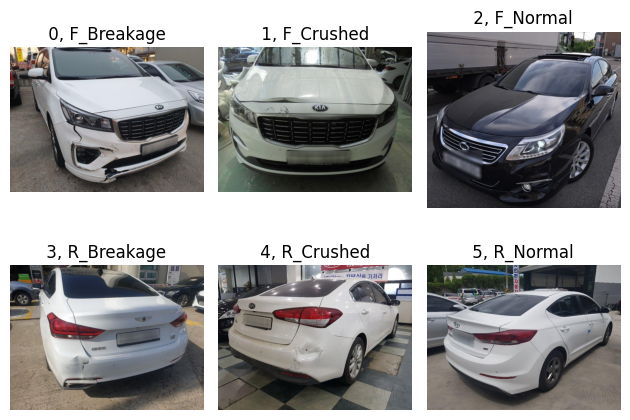

In [11]:
# Visualise the data

plt.figure(figsize = (12, 8))
fig, axes = plt.subplots(2, 3)

for i, ax in enumerate(axes.flat):
    idx = [j for j, k in enumerate(labels) if k==i]
    print(f"i: {i}, len(idx): {len(idx)}")
    
    if idx != None:
        print(f"First image of this class at index: {idx[0]}\n")
        
        ax.imshow(dataset[ idx[0] ])
        ax.set_title(f" {labels[idx[0]]}, {classes[labels[idx[0]]]} ")
        ax.axis('off')              

plt.tight_layout()
plt.show()


In [12]:
# statified split, 75% for training and 25% for val/test
train_temp = ds['train'].train_test_split(
                                            train_size         = 0.75,
                                            test_size          = 0.25,
                                            seed               = config.RANDOM_SEED,
                                            stratify_by_column = 'label' 
                                        ) 

print(f"train_temp:       {train_temp}")
print(f"type(train_temp): {type(train_temp)}")
print(f"len(train_temp):  {len(train_temp)}")


train_temp:       DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 1725
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 575
    })
})
type(train_temp): <class 'datasets.dataset_dict.DatasetDict'>
len(train_temp):  2


In [13]:
# statified split of the 25% in test, 60%/40% for val/test
val_test = train_temp['test'].train_test_split(
                                                train_size         = 0.50,
                                                test_size          = 0.50,
                                                seed               = config.RANDOM_SEED,
                                                stratify_by_column = 'label' 
                                            ) 

print(f"val_test:       {val_test}")
print(f"type(val_test): {type(val_test)}")
print(f"len(val_test):  {len(val_test)}")


val_test:       DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 287
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 288
    })
})
type(val_test): <class 'datasets.dataset_dict.DatasetDict'>
len(val_test):  2


In [14]:
# verify data split counts
train_ds = train_temp['train']
val_ds   = val_test['train']
test_ds  = val_test['test']

print(f"train_ds: {len(train_ds)}, type(train_ds): {type(train_ds)}")
print(f"val_ds:   {len(val_ds)}  , type(val_ds): {type(val_ds)}"), 
print(f"test_ds:  {len(test_ds)} , type(test_ds): {type(test_ds)}")




train_ds: 1725, type(train_ds): <class 'datasets.arrow_dataset.Dataset'>
val_ds:   287  , type(val_ds): <class 'datasets.arrow_dataset.Dataset'>
test_ds:  288 , type(test_ds): <class 'datasets.arrow_dataset.Dataset'>


In [15]:
# verify class distribution

for split, name in zip([train_ds, val_ds, test_ds], ['train', 'val','test']):
    #print(f"split:{split}, \nname:{name}")
    #print("----------------------------------")
    
    labels         = split['label']
    unique, counts = np.unique(labels, return_counts=True)
    #print(f"unique: {unique}, counts:{counts}")
    #print("----------------------------------")

    print(f"\n{name}: ")
    for a, b in zip(unique, counts):
        print(f"  {classes[a]}: {b}")



train: 
  F_Breakage: 375
  F_Crushed: 300
  F_Normal: 375
  R_Breakage: 225
  R_Crushed: 225
  R_Normal: 225

val: 
  F_Breakage: 62
  F_Crushed: 50
  F_Normal: 62
  R_Breakage: 38
  R_Crushed: 37
  R_Normal: 38

test: 
  F_Breakage: 63
  F_Crushed: 50
  F_Normal: 63
  R_Breakage: 37
  R_Crushed: 38
  R_Normal: 37


In [16]:
# L.min():300, W.min():225 => so, the images can be resized to 224 x 224

In [17]:
# with_transform creates a new 'view' of the dataset with the function applied
train_ds = train_ds.with_transform(apply_train_transform)
val_ds   = val_ds.with_transform(apply_val_test_transform)
test_ds  = test_ds.with_transform(apply_val_test_transform)

# Verify one batch
print(train_ds[0]['image'].shape) # Should show torch.Size([3, 224, 224])

torch.Size([3, 224, 224])


In [18]:
# Create DataLoader
train_loader = DataLoader( train_ds, batch_size=config.BATCH_SIZE , shuffle=True)
val_loader   = DataLoader( val_ds,   batch_size=config.BATCH_SIZE , shuffle=False)
test_loader  = DataLoader( test_ds,  batch_size=config.BATCH_SIZE , shuffle=False)


In [19]:
# HF dataset returns batches as dictionaries {'image': tensor, 'label': tensor}, not tuples as in our previous project
# for images, labels in train_loader: will not work here.
for batch in train_loader:
    images, labels = batch['image'], batch['label']
    print(f"images.shape: {images.shape}")
    print(f"labels.shape: {labels.shape}")
    break

print("---")
print(f"images[0].shape: {images[0].shape}, labels[0]: {labels[0]}, {classes[labels[0]]}")


images.shape: torch.Size([32, 3, 224, 224])
labels.shape: torch.Size([32])
---
images[0].shape: torch.Size([3, 224, 224]), labels[0]: 1, F_Crushed


 type(images[0]): <class 'torch.Tensor'> 


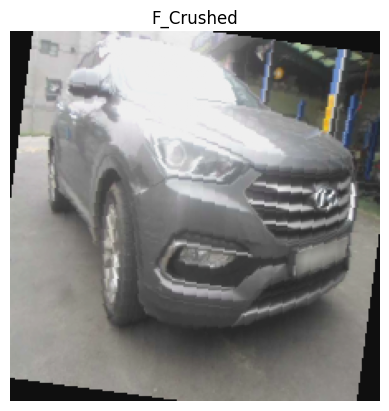

In [20]:
print(f" type(images[0]): {type(images[0])} ")

mean = torch.tensor( imagenet_mean )
std  = torch.tensor( imagenet_std )

img = images[0].permute(1, 2, 0)
img = (img*std + mean).clamp(0, 1)
plt.imshow( img )
plt.title( classes[labels[0]] )
plt.axis('off')
plt.show()


### MODEL 1: TRAINING WITH CNN

In [21]:
in_channels   = 3  # RGB image
out_channels  = 16 # most popular 
dropout_p     = 0.20


In [22]:
# Instantiate the class
model = CarClassifierCNN( in_channels     = 3, 
                             out_channels = 16, 
                             num_classes  = num_classes, 
                             dropout_p    = dropout_p ).to(config.DEVICE)

# Define loss fn or criteria
loss_fn = nn.CrossEntropyLoss()

# Define ADAM optimizer
optimizer = optim.Adam( model.parameters(), 
                        lr           = config.LEARNING_RATE,     # learning rate         (CAR SPEED)
                        betas        = (0.9, 0.999),             # Momentum of gradient  (HOW SMOOTHLY ACC/BRAKE IS APPLIED)
                        weight_decay = 1e-4)                     # L2 regularization     (FRICTION TO PREVENT SKIDDING)

# Define scheduler to update/change learning rate during optimization
scheduler = optim.lr_scheduler.ReduceLROnPlateau( optimizer, 
                                                  mode     = 'min', 
                                                  factor   = 0.1, 
                                                  patience = 3)


In [23]:
print('TP')

TP


In [24]:
# evauate accuracy on TEST data (seperate from train and val data)

start = time.time()

# Use 2 of 4 cores so that I can do other work side by side. 
torch.set_num_threads(config.SET_NUM_THREADS) 

# --- Capture the returned best weights ---
best_weights = train_model(  model        = model, 
                             epochs       = config.EPOCHS ,             
                             train_loader = train_loader,    # TRAIN DATA         
                             val_loader   = val_loader,      # VAL DATA       
                             loss_fn      = loss_fn, 
                             optimizer    = optimizer,
                             scheduler    = scheduler     )            

print(f"Total time taken to execute train_model() is : {(time.time()-start)/60} minutes")


---- Epoch [1/20], Batch [1/54], Batch_Loss 1.750 


---- Epoch [1/20], Batch [11/54], Batch_Loss 1.708 


---- Epoch [1/20], Batch [21/54], Batch_Loss 1.710 


---- Epoch [1/20], Batch [31/54], Batch_Loss 1.656 


---- Epoch [1/20], Batch [41/54], Batch_Loss 1.679 


...

---- Epoch [20/20], Batch [21/54], Batch_Loss 0.778 


---- Epoch [20/20], Batch [31/54], Batch_Loss 0.913 


---- Epoch [20/20], Batch [41/54], Batch_Loss 0.786 


---- Epoch [20/20], Batch [51/54], Batch_Loss 1.213 


Epoch [20/20], Train Loss: 0.982, Val Acc: 41.812%, Val Loss: 1.200, LR: 0.0001
Total time taken to execute train_model() is : 73.14159903128942 minutes


In [25]:
# --- Explicitly reload the best parameters (Epoch 7) into the model ---

model_dir  = Path(config.MODEL_DIR) 

print(model_dir, type(model_dir))

if best_weights is not None:
    model.load_state_dict(best_weights)
    print("-> Restored model parameters from the peak validation epoch for testing.")
    
    # --- NEW ADDITION: Save the best weights to the models folder ---
    # Uses the model_dir path defined at the top of the script
    save_file_path = model_dir / 'custom_CNN_custom_best.pth' 
    torch.save(best_weights, save_file_path)
    print(f"-> Successfully saved the best model weights to: {save_file_path}")

print("----------------------------------------------------------------------------")
# Evaluate accuracy on TEST data (seperate from train and val data)
# This will now correctly execute using the best Epoch 7 parameters instead of Epoch 10.
test_acc, _, y_pred, y_true = val_model(  model      = model,
                                          val_loader = test_loader, # TEST DATA
                                          loss_fn    = loss_fn)
print(f"Custom CNN Accuracy based on test data is : {test_acc:.2f} %")

/mnt/mydata/06.04.2026_home_laptop_backup/Downloads/Course3_AI_Bootcamp/Deep_Learning/ch13_Project_Car_Damage_Detection/car-damage-classifier/models <class 'pathlib.PosixPath'>
-> Restored model parameters from the peak validation epoch for testing.
-> Successfully saved the best model weights to: /mnt/mydata/06.04.2026_home_laptop_backup/Downloads/Course3_AI_Bootcamp/Deep_Learning/ch13_Project_Car_Damage_Detection/car-damage-classifier/models/custom_CNN_custom_best.pth
----------------------------------------------------------------------------


Custom CNN Accuracy based on test data is : 52.43 %


In [26]:
# Pass the outputs directly into scikit-learn functions
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

report = classification_report(y_true, y_pred, target_names=classes, zero_division=0)
print(report)


              precision    recall  f1-score   support

  F_Breakage       0.50      0.83      0.62        63
   F_Crushed       0.52      0.28      0.36        50
    F_Normal       1.00      0.54      0.70        63
  R_Breakage       0.37      0.78      0.50        37
   R_Crushed       0.25      0.11      0.15        38
    R_Normal       0.67      0.49      0.56        37

    accuracy                           0.52       288
   macro avg       0.55      0.50      0.48       288
weighted avg       0.58      0.52      0.51       288



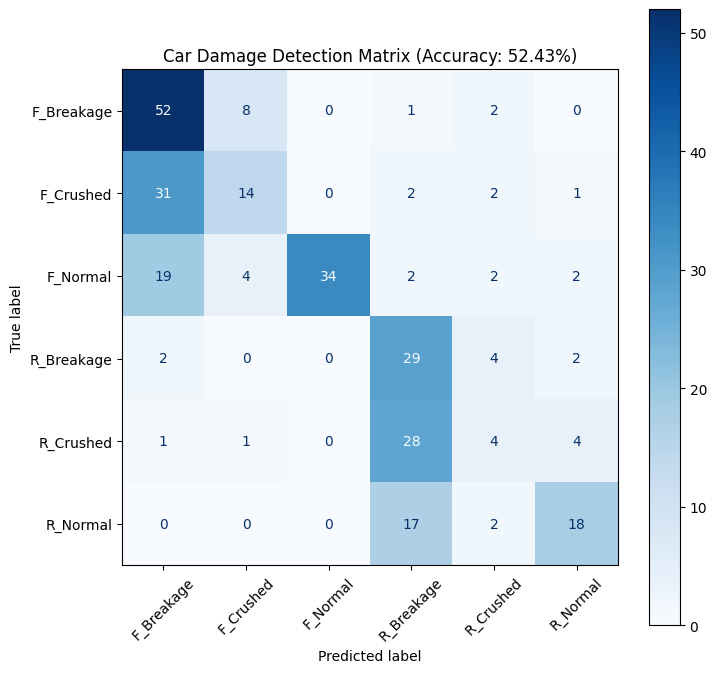

In [27]:
# confusion matrix 
cm = confusion_matrix(y_true, y_pred)

# Initialize and customize the visual display container
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=classes
)

# Plot the matrix onto a standard matplotlib canvas
fig, ax = plt.subplots(figsize=(8, 8)) # Give it an 8x8 inch canvas size for legibility
disp.plot(
    include_values=True,    # Show numerical counts inside each box
    cmap='Blues',           # Classic clean blue shading gradient
    ax=ax,                  # Bind it to our customized canvas size
    xticks_rotation=45      # Rotates labels by 45 degrees so they do not overlap
)

plt.title(f'Car Damage Detection Matrix (Accuracy: {test_acc:.2f}%)')
plt.show()

SUMMARY:
1. 2300 RBG images from Hugging Faces.
2. Six class classification problem
3. 75% - 12.5% - 12.5% split for train - validation - test runs
4. Train vs eval/test seperate transformations used
5. Training with custom CNN model resulted in 45.49% accuracy
6. Used best weights from 5 epochs only
7. Local computer training on cpu (not gpu), so light weight models used..